  # US Tariffs: Risks & Strategies - Report Generator

  ## Automated Analysis of Trade Tariff Risks and Corporate Mitigation Strategies

  ## Why It Matters







  In an era of increasing trade tensions and evolving geopolitical landscapes, companies face unprecedented uncertainty around import tariffs and trade barriers. Understanding corporate exposure to tariff risks across global supply chains is critical for investment decisions, risk management, and strategic planning. Manual tracking of tariff impacts across multiple companies and markets is time-intensive and often incomplete.

  ## What It Does







  This workflow combines the `RiskAnalyzer` class from the `bigdata-research-tools` and `GenerateReport` class to systematically analyze corporate exposure to US import tariff risks. Designed for portfolio managers, risk analysts, and trade compliance professionals, it transforms scattered information from news, filings, and earnings calls into a detailed research report covering risk intelligence and mitigation strategies.

  ## How It Works







  The workflow integrates **hybrid semantic search**, **AI-powered risk taxonomies**, and **multi-source content analysis** to deliver:







  - **Automated Risk Taxonomy Creation**: Uses RiskAnalyzer to generate hierarchical risk categories specific to tariff impacts



  - **Cross-Source Intelligence Gathering**: Searches news articles, SEC filings, and earnings transcripts for relevant discussions



  - **AI-Powered Risk Classification**: Categorizes content into specific risk scenarios





  - **Corporate Response Extraction**: Identifies and summarizes company mitigation plans from official communications



  - **Customizable Report Generation**: Produces professional HTML reports ranked by Media Attention, Financial Impact, and Uncertainty

  ## A Real-World Use Case







 This cookbook demonstrates the complete end-to-end workflow through analyzing how US import tariffs impact major American companies. You'll see how the system transforms scattered tariff discussions across news, SEC filings, and earnings transcripts into structured risk assessments, complete with corporate response strategies and quantified exposure metrics for investment and risk management decisions.

  ## Setup and Imports

  ## Async Compatibility Setup







  **Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:







  ### Why is this needed?







  Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:







  ```



  RuntimeError: asyncio.run() cannot be called from a running event loop



  ```







  The `nest_asyncio.apply()` command patches this to allow nested event loops.







  💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


  ## Environment Setup







  The following cell configures the necessary path for the analysis

In [2]:
import os
import sys


current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


  ## Optional: Plotly Display Configuration







  For better visualization rendering, you can also set the Plotly renderer:

In [3]:
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")

✅ Plotly configured for JupyterLab


  ## Configure Output Directories







  Set up the directory structure where analysis results and reports will be saved.

In [4]:
# Define output file paths for our report
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

  ## Load Credentials

In [5]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


  ## Connecting to Bigdata







  Create a Bigdata object with your credentials.

In [6]:
from bigdata_client import Bigdata

bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

  ## Import Required Libraries







  Import the core libraries needed for tariff risk analysis

In [7]:
from IPython.display import display, HTML

import pandas as pd
import numpy as np
from datetime import datetime

from src.report_generator import GenerateReport, theme_tree_to_dict
from bigdata_research_tools.workflows.risk_analyzer import RiskAnalyzer
from bigdata_client.models.search import DocumentType

  ## Defining the Analysis Parameters







  - **Main Theme** (`main_theme`): The central risk scenario to analyze across companies



  - **Focus** (`focus`): Expert perspective for generating targeted risk taxonomies



  - **Company Universe** (`my_watchlist_id`): The set of companies to analyze



  - **Model Selection** (`llm_model`): The AI model used for risk classification and summarization



  - **Time Period** (`start_date` and `end_date`): The date range for the analysis



  - **Frequency** (`freq`): The frequency of the date ranges to search over. Supported values:

     - `Y`: Yearly intervals.

     - `M`: Monthly intervals.

     - `W`: Weekly intervals.

     - `D`: Daily intervals. Defaults to `3M`.



  - **Document Limit** (`document_limit`): The maximum number of documents to return per query to Bigdata API.



  - **Batch Size** (`batch_size`): The number of entities to include in a single batched query.



  - **Rerank Threshold** (`rerank_threshold`): By setting this value, you’re enabling the cross-encoder which reranks the results and selects those whose relevance is above the percentile you specify (0.7 being the 70th percentile). More information on the re-ranker can be found [here](https://docs.bigdata.com/how-to-guides/rerank_search).





  - **Response From News** (`response_from_news`): Controls the `news_search_fallback` parameter. If `True`, when no response is found in transcripts/filings, the system uses News as fallback. In reports, fallback responses are annotated with `[From News]`. If `False`, missing responses show "No evidence of discussions found in Transcripts/Filings.". Default: `True`.





In [8]:
# ===== Customizable Parameters =====

# Company Universe (from Watchlist)
my_watchlist_id = 'fa589e57-c9e0-444d-801d-18c92d65389f' # Magnificent 7
watchlist = bigdata.watchlists.get(my_watchlist_id)
companies = bigdata.knowledge_graph.get_entities(watchlist.items)

# Main Analysis Theme
main_theme = 'US Import Tariffs Corporate Risk Impact Analysis'
focus = "Provide a detailed taxonomy of risks describing how new American import tariffs will impact worldwide companies, their operations and strategy."

# LLM Model Configuration
llm_model = "openai::gpt-4o-mini"

# Time Range Configuration
start_date = "2025-02-01"
end_date = "2025-08-13"
freq = 'M'  # Monthly search frequency

# Enable/Disable Reranker 
rerank_threshold = None

# Document Retrieval Limits
document_limit_news = 10
document_limit_filings = 5
batch_size = 1

# Toggle fallback to News for company responses
response_from_news = True



  ## Risk Analysis







  The first phase uses the `RiskAnalyzer` class to establish the foundation for our tariff impact analysis. This phase includes three critical steps that prepare the data for the report generation phase.

  ### Initialize RiskAnalyzer







  The `RiskAnalyzer` handles the initial risk discovery and taxonomy creation:



  - **Automated Taxonomy Generation**: Creates a hierarchical structure of tariff-related risks



  - **Semantic Content Retrieval**: Searches news articles using AI-powered semantic matching



  - **Intelligent Content Labeling**: Categorizes found content into specific risk scenarios







In [9]:
# Initialize RiskAnalyzer with tariff-specific parameters
analyzer = RiskAnalyzer(
    llm_model=llm_model,
    main_theme=main_theme,
    companies=companies,
    start_date=start_date,
    end_date=end_date,
    document_type=DocumentType.NEWS,
    sources=None,
    rerank_threshold=None,
    focus=focus,
)

  ### Generate Risk Taxonomy







  Create a comprehensive taxonomy that breaks down tariff risks into specific, analyzable categories such as supply chain disruption, pricing impacts, and market access challenges.

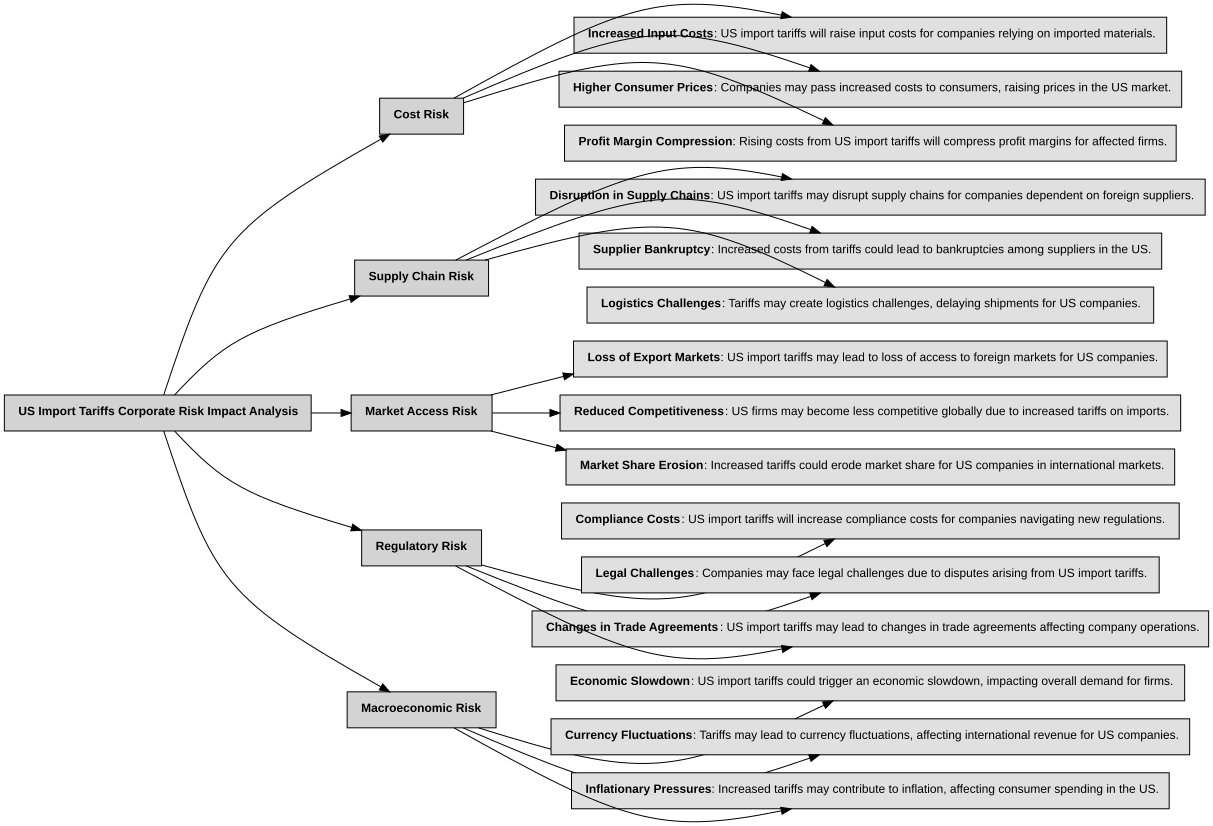

In [10]:
# Generate the comprehensive risk taxonomy
risk_tree, risk_summaries, terminal_labels = analyzer.create_taxonomy()
themes_tree_dict = {risk_tree.label: theme_tree_to_dict(risk_tree)}

# Visualize the taxonomy structure
risk_tree.visualize()

  The taxonomy tree shows how tariff risks branch into specific sub-scenarios. Each terminal node represents a distinct risk category that will be used to classify and analyze news content.

  ### Retrieve Relevant Content







  Search news articles using the generated taxonomy to find discussions about tariff impacts across our company universe.

In [11]:
# Search for tariff-related content in news articles
df_sentences_semantic = analyzer.retrieve_results(
    sentences=risk_summaries,
    freq=freq,
    document_limit=document_limit_news,
    batch_size=batch_size
)

Processing news results...: 100%|████████| 7350/7350 [00:00<00:00, 37050.15it/s]


  ### Labeling



  Use AI to analyze each news excerpt and categorize it into the appropriate risk scenarios. This creates structured data from unstructured news content.

In [12]:
# Classify news content into risk categories
df_labeled, _ = analyzer.label_search_results(
    df_sentences=df_sentences_semantic,
    terminal_labels=terminal_labels,
    risk_tree=risk_tree,
    additional_prompt_fields=['entity_sector','entity_industry', 'headline']
)

Querying OpenAI...: 100%|███████████████████| 4073/4073 [03:36<00:00, 18.84it/s]


  ## Report Generation



  The second phase uses `GenerateReport` and transforms the classified risk data into comprehensive reports with corporate mitigation strategies.

  ### Initialize GenerateReport







  The `GenerateReport` class will:



  - Create sector-wide risk summaries



  - Generate company-specific risk scores and summaries



  - Extract mitigation plans from SEC filings and earnings transcripts



  - Produce professional HTML reports with customizable ranking criteria

In [ ]:
# Initialize the report generator with our analysis parameters
report_generator = GenerateReport(
        watchlist_id=my_watchlist_id,
        main_theme=main_theme,
        focus=focus,
        llm_model='gpt-4o-mini',
        api_key=OPENAI_API_KEY,
        start_date=start_date,
        end_date=end_date,
        search_frequency=freq,
        document_limit_news=document_limit_news,
        document_limit_filings=document_limit_filings,
        bigdata=bigdata,
        batch_size=batch_size,
        themes_tree_dict=themes_tree_dict
)

  ### Generate Comprehensive Report







  Execute the complete report generation workflow including:



  1. **Sector-Level Summarization**: Create thematic summaries across risk categories



  2. **Company-Level Analysis**: Generate risk scores for Media Attention, Financial Impact, and Uncertainty



  3. **Mitigation Strategy Extraction**: Search filings and transcripts for corporate response plans (with News fallback when enabled via `news_search_fallback`)



  4. **Data Integration**: Combine all sources into structured report datasets

In [ ]:
# Generate the risk report data
report = report_generator.generate_report(
    df_labeled=df_labeled,
    news_search_fallback = response_from_news, # Use response_from_news to enable/disable News fallback
    import_from_path=None,
    export_to_path=output_dir,
)

Querying Bigdata...: 100%|████████████████████| 105/105 [00:22<00:00,  4.75it/s]


Completed 95 requests in 6.48 seconds.
Completed 250 requests in 6.94 seconds.
Completed 128 requests in 4.68 seconds.
Completed 174 requests in 6.66 seconds.
Completed 78 requests in 5.49 seconds.
Completed 44 requests in 4.38 seconds.
Completed 232 requests in 32.04 seconds.
Completed 58 requests in 5.90 seconds.
Completed 235 requests in 24.89 seconds.
Completed 112 requests in 4.44 seconds.
Completed 202 requests in 8.76 seconds.
Completed 93 requests in 5.46 seconds.
Completed 62 requests in 7.09 seconds.
Completed 95 requests in 6.84 seconds.


  ## Final Output



  Transform the analysis results into professional, customizable reports. The system provides two distinct presentation styles, each optimized for different use cases and audiences.

  ### Report Customization Options







  Both report formats allow customization through multiple ranking criteria:







  **Sector-Wide Analysis**:



  - Identifies the most significant tariff risks across all companies



  - Ranks themes by media attention and document frequency



  - Provides executive summaries for each risk category







  **Company-Specific Analysis**:



  - **Most Reported Issue**: Highest media coverage and attention



  - **Biggest Risk**: Greatest potential financial impact



  - **Most Uncertain Issue**: Highest uncertainty scores and ambiguity







  Each company analysis includes extracted mitigation plans from official corporate communications, providing actionable intelligence for investment and risk management decisions.

  ### Report Format 1: Executive Summary Style







  This format prioritizes clarity and executive readability, focusing on the top risks per company across three key dimensions. Ideal for senior management briefings and board presentations.

In [22]:
from src.html_report import generate_html_report, prepare_data_report_0

# Extract report data for processing
df_by_theme = report.report_by_theme
df_by_company_with_responses = report.report_by_company

# Prepare data with executive summary formatting
top_by_theme, top_by_company = prepare_data_report_0(df_by_theme, df_by_company_with_responses)

# Generate executive-style HTML report
html_content = generate_html_report(top_by_theme, top_by_company, 'US Import Tariffs: Corporate Risk Impact Analysis')

# Save the executive report
report_filename = f'{output_dir}/tariffs_executive_report.html'
with open(report_filename, 'w') as file:
     file.write(html_content)

print(f"✅ Executive Report saved: {report_filename}")

✅ Executive Report saved: output/tariffs_executive_report.html


  #### Display Executive Report

In [23]:
display(HTML(html_content))

  ### Report Format 2: Detailed Analysis Version







  This format provides comprehensive risk analysis with extended company coverage and detailed risk breakdowns. Designed for analysts, portfolio managers, and risk management teams requiring in-depth insights.

In [24]:
from src.html_report import generate_html_report_v1, prepare_data_report_1

# Prepare data with detailed analysis formatting
top_by_theme, top_by_company = prepare_data_report_1(df_by_theme, df_by_company_with_responses)

# Generate detailed analysis HTML report
html_content_detailed = generate_html_report_v1(top_by_theme, top_by_company, 'US Import Tariffs: Comprehensive Risk Analysis')

# Save the detailed report
detailed_filename = f'{output_dir}/tariffs_detailed_analysis.html'
with open(detailed_filename, 'w') as file:
     file.write(html_content_detailed)

print(f"✅ Detailed Analysis Report saved: {detailed_filename}")

✅ Detailed Analysis Report saved: output/tariffs_detailed_analysis.html


  #### Display Detailed Analysis Report

In [25]:
display(HTML(html_content_detailed))

  ### Export Results for Further Analysis







  The generated data can be exported for integration with existing risk management systems, portfolio optimization tools, or compliance reporting workflows.

In [26]:
# Optional: Export structured data for external analysis
try:
    # Export the core datasets
    df_by_theme.to_csv(f'{output_dir}/tariffs_risks_by_theme.csv', index=False)
    df_by_company_with_responses.to_csv(f'{output_dir}/tariffs_risks_by_company.csv', index=False)
    
    print("✅ Data exported successfully:")
    print(f"   - Thematic analysis: {output_dir}/tariffs_risks_by_theme.csv")
    print(f"   - Company analysis: {output_dir}/tariffs_risks_by_company.csv")
    print(f"   - Executive report: {output_dir}/tariffs_executive_report.html")
    print(f"   - Detailed analysis: {output_dir}/tariffs_detailed_analysis.html")
    
except Exception as e:
    print(f"Warning: Export failed - {e}")

✅ Data exported successfully:
   - Thematic analysis: output/tariffs_risks_by_theme.csv
   - Company analysis: output/tariffs_risks_by_company.csv
   - Executive report: output/tariffs_executive_report.html
   - Detailed analysis: output/tariffs_detailed_analysis.html
